# Notebook 4.1 — Publication-Grade Statistical Robustness
### 10-Seed Cross-Dataset CIs + Wilcoxon (Holm + BH-FDR) + Aggregate Meta-Tests
**EAAI/ESWA-Grade Statistical Evidence — Final Version**

This notebook upgrades Notebook 4 to **10 seeds per cell** to give Holm–Bonferroni correction
sufficient statistical power. With n=10 paired observations, the minimum achievable one-tailed
Wilcoxon p-value is 2⁻¹⁰ ≈ 0.001, allowing Holm-corrected significance to be detected even
across 13–26 simultaneous tests.

**Statistical rigour (full publication standard):**
1. **10 random seeds** per (method, scenario, train, test) cell
2. **Per-cell Wilcoxon** with two parallel multiple-comparison corrections:
   - Holm–Bonferroni (FWER control)
   - Benjamini–Hochberg (FDR control)
3. **Aggregate meta-tests** pooling all (cell × seed) paired observations
4. **Confidence intervals** (95% Student-t, n=10)
5. **Effect-size estimates** (Cohen's d, rank-biserial r)

**Outputs:**
- `cross_dataset_10seed_results.csv` (raw)
- `cross_dataset_summary_with_CI.csv` (per-cell aggregates)
- `wilcoxon_significance.csv` (per-cell tests, Holm + BH-FDR)
- `aggregate_meta_tests.csv` (Table 5 of paper)
- `figure5_v3_transfer_with_CI_and_sig.pdf` (publication Figure 5)
- `figure5_supp_significance_heatmap.pdf` (supplementary)

**Compute estimate:** ~2.0–2.5 GPU-hours on Kaggle T4.
**Inputs (Kaggle Add Data):** same five datasets as Notebook 4.


In [1]:
%%capture
!pip install transformers accelerate scikit-learn scipy matplotlib seaborn pillow requests -q


In [2]:
import os, sys, json, time, warnings, gc
import numpy as np
import pandas as pd
from copy import deepcopy
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon, t as student_t, rankdata
from sklearn.metrics import f1_score, balanced_accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedShuffleSplit
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR
from PIL import Image
import requests
from concurrent.futures import ThreadPoolExecutor, as_completed

warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU: {p.name}  | VRAM {p.total_memory/1e9:.1f} GB")


Device: cuda
GPU: Tesla T4  | VRAM 15.6 GB


In [3]:
CFG = dict(
    bdse_feat_dir       = '/kaggle/input/datasets/rohulaminlabid/phase1-nb2-inputs',
    manifests_dir       = '/kaggle/input/datasets/rohulaminlabid/benchmard-datasets',
    phase1_results_dir  = '/kaggle/input/datasets/rohulaminlabid/results-indomainv2',
    shanbalico_img_dir  = '/kaggle/input/datasets/danielshanbalico/dog-emotion/Dog Emotion',
    devzohaib_img_dir   = '/kaggle/input/datasets/devzohaib/dog-emotions-prediction/images',
    debiw_img_dir       = '/kaggle/input/datasets/rohulaminlabid/debiw-dataset',
    feat_cache_dir      = '/kaggle/working/feat_cache',
    output_dir          = '/kaggle/working/nb41_outputs',

    siglip_id           = 'google/siglip-base-patch16-224',
    feat_dim            = 768,
    extract_batch       = 64,

    n_proto_per_class   = 6,
    tau                 = 0.07,
    lambda_anchor       = 0.1,
    mu_div              = 0.05,
    lr                  = 1e-3,
    epochs              = 150,
    patience            = 20,
    batch_size          = 256,

    # ── 10 seeds (was 5 in NB4) ─────────────────────────────────────────────
    seeds = [13, 42, 101, 257, 999, 1234, 2024, 31337, 7777, 5050],
    indomain_test_frac = 0.20,
    ci_alpha = 0.05,

    classes3 = ['A', 'N', 'H'],
    classes2 = ['A', 'N'],
    debiw_workers = 20,
    debiw_timeout = 12,
    debiw_retries = 2,
)
for d in [CFG['debiw_img_dir'], CFG['feat_cache_dir'], CFG['output_dir']]:
    os.makedirs(d, exist_ok=True)
CLASS3_TO_IDX = {c:i for i,c in enumerate(CFG['classes3'])}
CLASS2_TO_IDX = {c:i for i,c in enumerate(CFG['classes2'])}
print(f"Seeds: {CFG['seeds']}")
print(f"N seeds: {len(CFG['seeds'])}  → min Wilcoxon p (one-tailed) = 2^-10 = {2**-10:.5f}")
print(f"After Holm × 13 tests: min adjusted p = {13 * 2**-10:.5f}  → ★★★ achievable")


Seeds: [13, 42, 101, 257, 999, 1234, 2024, 31337, 7777, 5050]
N seeds: 10  → min Wilcoxon p (one-tailed) = 2^-10 = 0.00098
After Holm × 13 tests: min adjusted p = 0.01270  → ★★★ achievable


In [11]:
# Load SigLIP once; keep frozen on GPU for feature extraction
from transformers import AutoProcessor, AutoModel

print("Loading SigLIP-Base/16 …")
_siglip_processor = AutoProcessor.from_pretrained(CFG['siglip_id'])
_siglip_model     = AutoModel.from_pretrained(CFG['siglip_id']).to(DEVICE).eval()
for p in _siglip_model.parameters():
    p.requires_grad_(False)
print("SigLIP loaded.")

def siglip_image_features(image_paths, batch_size=None):
    """Return L2-normalised SigLIP image features (N, 768) for a list of paths.
    Invalid / missing images are replaced with zero vectors; returned valid_mask
    is a boolean array marking which rows are real."""
    bs = batch_size or CFG['extract_batch']
    all_feats, valid_mask = [], []
    for i in range(0, len(image_paths), bs):
        batch = image_paths[i:i+bs]
        imgs, ok = [], []
        for p in batch:
            try:
                imgs.append(Image.open(p).convert('RGB'))
                ok.append(True)
            except Exception:
                imgs.append(Image.new('RGB', (224, 224), 0))
                ok.append(False)
        inp = _siglip_processor(images=imgs, return_tensors='pt', padding=True)
        inp = {k: v.to(DEVICE) for k, v in inp.items()}
        with torch.no_grad():
            outputs = _siglip_model.get_image_features(**inp)
            feats = outputs.pooler_output  # This extracts the actual feature tensor
            feats = F.normalize(feats, dim=1)
        all_feats.append(feats.cpu().numpy())
        valid_mask.extend(ok)
        if (i // bs) % 20 == 0:
            print(f"  {i+len(batch)}/{len(image_paths)} images processed", end='\r')
    print()
    return np.concatenate(all_feats, axis=0), np.array(valid_mask, dtype=bool)

def siglip_text_features(texts):
    """Return L2-normalised SigLIP text features for a list of strings."""
    inp = _siglip_processor(text=texts, return_tensors='pt', padding=True, truncation=True)
    inp = {k: v.to(DEVICE) for k, v in inp.items()}
    with torch.no_grad():
        outputs = _siglip_model.get_image_features(**inp)
        feats = outputs.pooler_output  # This extracts the actual tensor
        feats = F.normalize(feats, dim=1)
    return feats.cpu().numpy()

def cache_path(name):
    return os.path.join(CFG['feat_cache_dir'], f'{name}.npy')

def load_or_extract(name, image_paths, label_array):
    """Load cached features or extract and cache them."""
    fp = cache_path(name)
    fp_meta = fp.replace('.npy', '_meta.csv')
    if os.path.exists(fp) and os.path.exists(fp_meta):
        print(f"[cache hit] {name}")
        feats = np.load(fp)
        meta  = pd.read_csv(fp_meta)
        return feats, meta
    print(f"[extracting] {name} ({len(image_paths)} images) …")
    feats, valid = siglip_image_features(image_paths)
    meta = pd.DataFrame({'path': image_paths, 'label': label_array, 'valid': valid})
    np.save(fp, feats)
    meta.to_csv(fp_meta, index=False)
    print(f"  Saved to {fp}")
    return feats, meta


Loading SigLIP-Base/16 …


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

SigLIP loaded.


In [6]:
print("Loading BDSE Phase 1 artifacts …")
bdse_feats_siglip = np.load(os.path.join(CFG['bdse_feat_dir'], 'features_siglip.npy'))
bdse_feat_index   = pd.read_csv(os.path.join(CFG['bdse_feat_dir'], 'feature_index.csv'))
text_anchors_np   = np.load(os.path.join(CFG['bdse_feat_dir'], 'text_anchors_siglip.npy'))
text_anchors_meta = pd.read_csv(os.path.join(CFG['bdse_feat_dir'], 'text_anchors_meta.csv'))

# Splits
splits_path = os.path.join(
    '/kaggle/input/datasets/rohulaminlabid/phase1-nb2-inputs',
    'bdse_dogid_splits.csv'
)

bdse_splits = pd.read_csv(splits_path)
print(bdse_splits)


bdse_merged = bdse_feat_index.merge(bdse_splits[['image_id','dog_id','label','fold']],
                                     on='image_id', how='inner')

bdse_X = bdse_feats_siglip[bdse_merged.index.values]
bdse_y = bdse_merged['label_x'].map(CLASS3_TO_IDX).values
bdse_folds = bdse_merged['fold'].values

# ADaS
adas_cols = ['n_A', 'n_N', 'n_H']
if all(c in bdse_merged.columns for c in adas_cols):
    totals = bdse_merged[adas_cols].sum(axis=1).clip(lower=1)
    bdse_soft = (bdse_merged[adas_cols].values / totals.values[:,None]).astype(np.float32)
    bdse_wts  = (totals / totals.max()).values.astype(np.float32)
else:
    bdse_soft = np.eye(3)[bdse_y].astype(np.float32)
    bdse_wts  = np.ones(len(bdse_y), dtype=np.float32)

TEXT_ANCHORS = torch.tensor(text_anchors_np, dtype=torch.float32)
PROTO_CLASS_MAP3 = {0: list(range(0,6)), 1: list(range(6,12)), 2: list(range(12,18))}
PROTO_CLASS_MAP2 = {0: list(range(0,6)), 1: list(range(6,12))}

print(f"BDSE rows: {len(bdse_merged)}  classes: {dict(zip(*np.unique(bdse_y, return_counts=True)))}")
print(f"Text anchors: {TEXT_ANCHORS.shape}")

Loading BDSE Phase 1 artifacts …
     image_id    dog_id label  fold
0    BDSE_001  dog_0193     N     3
1    BDSE_002  dog_0299     A     2
2    BDSE_003  dog_0197     A     1
3    BDSE_004  dog_0436     H     2
4    BDSE_005  dog_0340     H     2
..        ...       ...   ...   ...
495  BDSE_497  dog_0346     H     4
496  BDSE_498  dog_0027     N     2
497  BDSE_499  dog_0008     N     4
498  BDSE_500  dog_0217     A     2
499  BDSE_501  dog_0246     A     4

[500 rows x 4 columns]
BDSE rows: 500  classes: {np.int64(0): np.int64(200), np.int64(1): np.int64(202), np.int64(2): np.int64(98)}
Text anchors: torch.Size([18, 768])


In [8]:


debiw_manifest = pd.read_csv(os.path.join(CFG['manifests_dir'], 'debiw_processed.csv'))



In [12]:
shan_manifest = pd.read_csv(os.path.join(CFG['manifests_dir'], 'shanbalico_processed.csv'))
shan_main     = shan_manifest[shan_manifest['bdse_used_for_main_eval']==True].reset_index(drop=True)
def resolve_shan(fp):
    fn = os.path.basename(fp); cls = fp.split('/')[-2]
    return os.path.join(CFG['shanbalico_img_dir'], cls, fn)
shan_paths = [resolve_shan(p) for p in shan_main['filepath']]
shan_X_raw, shan_meta = load_or_extract('shanbalico_main', shan_paths, shan_main['bdse_label'].values)
shan_valid = shan_meta['valid'].values.astype(bool)
shan_X  = shan_X_raw[shan_valid]
shan_y3 = shan_meta['label'][shan_valid].map(CLASS3_TO_IDX).values
print(f"Shanbalico: {shan_X.shape}  classes: {dict(zip(*np.unique(shan_y3, return_counts=True)))}")

dev_manifest = pd.read_csv(os.path.join(CFG['manifests_dir'], 'devzohaib_processed.csv'))
dev_main     = dev_manifest[dev_manifest['bdse_used_for_main_eval']==True].reset_index(drop=True)
def resolve_dev(fp):
    parts = fp.split('/'); return os.path.join(CFG['devzohaib_img_dir'], parts[-2], parts[-1])
dev_paths = [resolve_dev(p) for p in dev_main['filepath']]
dev_X_raw, dev_meta = load_or_extract('devzohaib_main', dev_paths, dev_main['bdse_label'].values)
dev_valid = dev_meta['valid'].values.astype(bool)
dev_X  = dev_X_raw[dev_valid]
dev_y3 = dev_meta['label'][dev_valid].map(CLASS3_TO_IDX).values
print(f"Devzohaib : {dev_X.shape}  classes: {dict(zip(*np.unique(dev_y3, return_counts=True)))}")

debiw_main = debiw_manifest[debiw_manifest['bdse_used_for_main_eval']==True].reset_index(drop=True)
debiw_paths = [os.path.join(CFG['debiw_img_dir'], fn) for fn in debiw_main['image_filename']]
debiw_X_raw, debiw_meta = load_or_extract('debiw_main', debiw_paths, debiw_main['bdse_label'].values)
debiw_valid = debiw_meta['valid'].values.astype(bool)
debiw_X  = debiw_X_raw[debiw_valid]
debiw_y2 = debiw_meta['label'][debiw_valid].map(CLASS2_TO_IDX).values
print(f"DEBIw     : {debiw_X.shape}  classes: {dict(zip(*np.unique(debiw_y2, return_counts=True)))}")


[extracting] shanbalico_main (3000 images) …
  2624/3000 images processed
  Saved to /kaggle/working/feat_cache/shanbalico_main.npy
Shanbalico: (3000, 768)  classes: {np.int64(0): np.int64(1000), np.int64(1): np.int64(1000), np.int64(2): np.int64(1000)}
[extracting] devzohaib_main (8410 images) …
  7744/8410 images processed
  Saved to /kaggle/working/feat_cache/devzohaib_main.npy
Devzohaib : (8410, 768)  classes: {np.int64(0): np.int64(1549), np.int64(1): np.int64(3057), np.int64(2): np.int64(3804)}
[extracting] debiw_main (5335 images) …


The channel dimension is ambiguous. Got image shape torch.Size([3, 1, 1]). Assuming channels are the first dimension. Use the [input_data_format](https://huggingface.co/docs/transformers/main/internal/image_processing_utils#transformers.image_transforms.rescale.input_data_format) parameter to assign the channel dimension.


  5184/5335 images processed
  Saved to /kaggle/working/feat_cache/debiw_main.npy
DEBIw     : (5335, 768)  classes: {np.int64(0): np.int64(1298), np.int64(1): np.int64(4037)}


In [13]:
class PEACEHead(nn.Module):
    def __init__(self, text_anchors, proto_class_map, tau=0.07,
                 lambda_anchor=0.1, mu_div=0.05):
        super().__init__()
        ta_norm = F.normalize(text_anchors.float(), dim=1)
        self.register_buffer('text_anchors', ta_norm)
        self.prototypes = nn.Parameter(ta_norm.clone())
        self.proto_class_map = proto_class_map
        self.n_classes = len(proto_class_map)
        self.tau, self.lambda_anchor, self.mu_div = tau, lambda_anchor, mu_div
    def forward(self, x):
        x_n = F.normalize(x, dim=1)
        p_n = F.normalize(self.prototypes, dim=1)
        sims = (x_n @ p_n.T) / self.tau
        out = []
        for c in range(self.n_classes):
            out.append(torch.logsumexp(sims[:, self.proto_class_map[c]], dim=1, keepdim=True))
        return torch.cat(out, dim=1)
    def logits_2class(self, x):
        x_n = F.normalize(x, dim=1)
        p_n = F.normalize(self.prototypes, dim=1)
        sims = (x_n @ p_n.T) / self.tau
        out = []
        for c in [0,1]:
            idx = self.proto_class_map.get(c, [c*6+j for j in range(6)])
            out.append(torch.logsumexp(sims[:, idx], dim=1, keepdim=True))
        return torch.cat(out, dim=1)
    def anchor_loss(self):
        return torch.mean((F.normalize(self.prototypes, dim=1) - self.text_anchors)**2)
    def diversity_loss(self):
        p_n = F.normalize(self.prototypes, dim=1)
        sim = p_n @ p_n.T
        n = p_n.size(0)
        mask = ~torch.eye(n, dtype=torch.bool, device=p_n.device)
        return sim[mask].mean()
    def aux_loss(self):
        return self.lambda_anchor * self.anchor_loss() + self.mu_div * self.diversity_loss()


class ProtoPNetHead(nn.Module):
    def __init__(self, feat_dim, n_classes, n_proto_per_class=1, tau=0.07):
        super().__init__()
        self.n_proto_per_class = n_proto_per_class
        self.prototypes = nn.Parameter(torch.randn(n_classes*n_proto_per_class, feat_dim))
        self.n_classes = n_classes; self.tau = tau
        self.proto_to_class = torch.tensor(
            [c for c in range(n_classes) for _ in range(n_proto_per_class)], dtype=torch.long)
    def forward(self, x):
        x_n = F.normalize(x, dim=1)
        p_n = F.normalize(self.prototypes, dim=1)
        sims = (x_n @ p_n.T) / self.tau
        out = []
        for c in range(self.n_classes):
            idx = (self.proto_to_class == c).nonzero(as_tuple=True)[0]
            out.append(torch.logsumexp(sims[:, idx], dim=1, keepdim=True))
        return torch.cat(out, dim=1)


def make_peace(n_classes=3, device=DEVICE, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    pcm = PROTO_CLASS_MAP3 if n_classes==3 else PROTO_CLASS_MAP2
    ta  = TEXT_ANCHORS if n_classes==3 else TEXT_ANCHORS[:12]
    return PEACEHead(ta, pcm, tau=CFG['tau'],
                     lambda_anchor=CFG['lambda_anchor'],
                     mu_div=CFG['mu_div']).to(device)


In [14]:
def train_peace(X_tr, y_tr, soft_labels=None, sample_weights=None,
                n_classes=3, seed=42, device=DEVICE):
    torch.manual_seed(seed); np.random.seed(seed)
    X_t = torch.tensor(X_tr, dtype=torch.float32)
    y_t = torch.tensor(y_tr, dtype=torch.long)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=seed)
    tr_idx, vl_idx = next(sss.split(X_tr, y_tr))
    X_trn, X_vl = X_t[tr_idx], X_t[vl_idx]
    y_trn, y_vl = y_t[tr_idx], y_t[vl_idx]
    if soft_labels is not None:
        sl_trn = torch.tensor(soft_labels[tr_idx], dtype=torch.float32)
        wt_trn = torch.tensor(sample_weights[tr_idx], dtype=torch.float32)
    else:
        sl_trn = F.one_hot(y_trn, n_classes).float()
        wt_trn = torch.ones(len(y_trn))
    tr_dl = DataLoader(TensorDataset(X_trn, y_trn, sl_trn, wt_trn),
                       batch_size=CFG['batch_size'], shuffle=True)
    model = make_peace(n_classes, device, seed)
    opt = Adam(model.parameters(), lr=CFG['lr'], weight_decay=1e-4)
    sch = CosineAnnealingLR(opt, T_max=CFG['epochs'])
    best_f1, best_state, no_imp = 0.0, None, 0
    for ep in range(CFG['epochs']):
        model.train()
        for xb, _, sl, wt in tr_dl:
            xb, sl, wt = xb.to(device), sl.to(device), wt.to(device)
            logits = model(xb)
            ce = -(sl * F.log_softmax(logits, dim=1)).sum(dim=1)
            loss = (wt * ce).mean() + model.aux_loss()
            opt.zero_grad(); loss.backward(); opt.step()
        sch.step()
        model.eval()
        with torch.no_grad():
            vp = model(X_vl.to(device)).argmax(1).cpu().numpy()
        vf1 = f1_score(y_vl.numpy(), vp, average='macro', zero_division=0)
        if vf1 > best_f1:
            best_f1, best_state, no_imp = vf1, deepcopy(model.state_dict()), 0
        else: no_imp += 1
        if no_imp >= CFG['patience']: break
    model.load_state_dict(best_state); model.eval()
    return model

def train_protopnet(X_tr, y_tr, n_classes=3, seed=42, device=DEVICE):
    torch.manual_seed(seed); np.random.seed(seed)
    X_t = torch.tensor(X_tr, dtype=torch.float32)
    y_t = torch.tensor(y_tr, dtype=torch.long)
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.1, random_state=seed)
    tr_idx, vl_idx = next(sss.split(X_tr, y_tr))
    tr_dl = DataLoader(TensorDataset(X_t[tr_idx], y_t[tr_idx]),
                       batch_size=CFG['batch_size'], shuffle=True)
    model = ProtoPNetHead(CFG['feat_dim'], n_classes,
                          n_proto_per_class=CFG['n_proto_per_class'],
                          tau=CFG['tau']).to(device)
    opt = Adam(model.parameters(), lr=CFG['lr'], weight_decay=1e-4)
    sch = CosineAnnealingLR(opt, T_max=CFG['epochs'])
    best_f1, best_state, no_imp = 0.0, None, 0
    for ep in range(CFG['epochs']):
        model.train()
        for xb, yb in tr_dl:
            loss = F.cross_entropy(model(xb.to(device)), yb.to(device))
            opt.zero_grad(); loss.backward(); opt.step()
        sch.step()
        model.eval()
        with torch.no_grad():
            vp = model(X_t[vl_idx].to(device)).argmax(1).cpu().numpy()
        vf1 = f1_score(y_t[vl_idx].numpy(), vp, average='macro', zero_division=0)
        if vf1 > best_f1:
            best_f1, best_state, no_imp = vf1, deepcopy(model.state_dict()), 0
        else: no_imp += 1
        if no_imp >= CFG['patience']: break
    model.load_state_dict(best_state); model.eval()
    return model

def train_siglip_lp(X_tr, y_tr, n_classes=3, seed=42):
    return LogisticRegression(max_iter=1000, C=1.0,
                              multi_class='multinomial', solver='lbfgs',
                              random_state=seed).fit(X_tr, y_tr)

def _ece(probs, onehot, n_bins=15):
    conf = probs.max(1)
    acc  = (probs.argmax(1) == onehot.argmax(1)).astype(float)
    bins = np.linspace(0, 1, n_bins+1)
    e = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 0:
            e += m.sum() * abs(conf[m].mean() - acc[m].mean())
    return e / len(conf)

def evaluate(model, kind, X_te, y_te, n_classes=3, two_class_mode=False, device=DEVICE):
    if kind == 'PEACE':
        X_t = torch.tensor(X_te, dtype=torch.float32).to(device)
        with torch.no_grad():
            logits = model.logits_2class(X_t) if two_class_mode else model(X_t)
            probs = F.softmax(logits, dim=1).cpu().numpy()
    elif kind == 'ProtoPNet':
        X_t = torch.tensor(X_te, dtype=torch.float32).to(device)
        with torch.no_grad():
            probs = F.softmax(model(X_t), dim=1).cpu().numpy()
    elif kind == 'SigLIP_LP':
        probs = model.predict_proba(X_te)
    preds = probs.argmax(1)
    nc = probs.shape[1]
    classes = list(range(nc))
    mf1 = f1_score(y_te, preds, average='macro', labels=classes, zero_division=0)
    bal = balanced_accuracy_score(y_te, preds)
    pcf1 = f1_score(y_te, preds, average=None, labels=classes, zero_division=0).tolist()
    ece = _ece(probs, np.eye(nc)[y_te])
    return dict(macro_f1=mf1, balanced_acc=bal, per_class_f1=pcf1, ece=ece, preds=preds, probs=probs)


In [15]:
def make_indomain_split(X, y, seed):
    sss = StratifiedShuffleSplit(n_splits=1, test_size=CFG['indomain_test_frac'],
                                  random_state=seed)
    return next(sss.split(X, y))

seed_splits = {}
for seed in CFG['seeds']:
    seed_splits[seed] = {
        'shan':  make_indomain_split(shan_X,  shan_y3, seed),
        'dev':   make_indomain_split(dev_X,   dev_y3,  seed),
        'debiw': make_indomain_split(debiw_X, debiw_y2, seed),
    }
print(f"Per-seed splits cached for {len(CFG['seeds'])} seeds")

all_results = []
def record(method, scenario, train_src, test_tgt, seed, n_classes, res, note=''):
    row = dict(method=method, scenario=scenario, train_src=train_src, test_tgt=test_tgt,
               seed=seed, n_classes=n_classes, note=note,
               macro_f1=round(res['macro_f1'], 6),
               balanced_acc=round(res['balanced_acc'], 6),
               ece=round(res['ece'], 6))
    pcf1 = res.get('per_class_f1', [])
    for i, lab in enumerate((['A','N','H'] if n_classes==3 else ['A','N'])):
        row[f'f1_{lab}'] = round(pcf1[i], 6) if i < len(pcf1) else None
    all_results.append(row)


Per-seed splits cached for 10 seeds


In [16]:
print("=" * 65)
print("SCENARIO A (10 seeds): BDSE → {Shan, Dev, DEBIw(A/N)}")
print("=" * 65)

t_start = time.time()
for seed in CFG['seeds']:
    # Train all 3 methods on full BDSE once per seed
    m_p  = train_peace(bdse_X, bdse_y, bdse_soft, bdse_wts, 3, seed)
    m_sl = train_siglip_lp(bdse_X, bdse_y, 3, seed)
    m_pp = train_protopnet(bdse_X, bdse_y, 3, seed)

    # → Shanbalico
    record('PEACE',     'A_BDSE_to_Ext', 'BDSE', 'Shanbalico', seed, 3,
           evaluate(m_p, 'PEACE', shan_X, shan_y3, 3))
    record('SigLIP_LP', 'A_BDSE_to_Ext', 'BDSE', 'Shanbalico', seed, 3,
           evaluate(m_sl, 'SigLIP_LP', shan_X, shan_y3, 3))
    record('ProtoPNet', 'A_BDSE_to_Ext', 'BDSE', 'Shanbalico', seed, 3,
           evaluate(m_pp, 'ProtoPNet', shan_X, shan_y3, 3))

    # → Devzohaib
    record('PEACE',     'A_BDSE_to_Ext', 'BDSE', 'Devzohaib', seed, 3,
           evaluate(m_p, 'PEACE', dev_X, dev_y3, 3))
    record('SigLIP_LP', 'A_BDSE_to_Ext', 'BDSE', 'Devzohaib', seed, 3,
           evaluate(m_sl, 'SigLIP_LP', dev_X, dev_y3, 3))
    record('ProtoPNet', 'A_BDSE_to_Ext', 'BDSE', 'Devzohaib', seed, 3,
           evaluate(m_pp, 'ProtoPNet', dev_X, dev_y3, 3))

    # → DEBIw (2-class for PEACE & ProtoPNet via 2-class subset of training labels for SigLIP_LP)
    r_p_db = evaluate(m_p, 'PEACE', debiw_X, debiw_y2, 3, two_class_mode=True)
    r_p_db['macro_f1']   = f1_score(debiw_y2, r_p_db['preds'], average='macro', labels=[0,1], zero_division=0)
    r_p_db['per_class_f1'] = f1_score(debiw_y2, r_p_db['preds'], average=None, labels=[0,1], zero_division=0).tolist()
    record('PEACE', 'A_BDSE_to_Ext', 'BDSE', 'DEBIw(A/N)', seed, 2, r_p_db, '2-class')

    an_mask = bdse_y < 2
    m_sl2 = train_siglip_lp(bdse_X[an_mask], bdse_y[an_mask], 2, seed)
    record('SigLIP_LP', 'A_BDSE_to_Ext', 'BDSE', 'DEBIw(A/N)', seed, 2,
           evaluate(m_sl2, 'SigLIP_LP', debiw_X, debiw_y2, 2), '2-class')

    record('ProtoPNet', 'A_BDSE_to_Ext', 'BDSE', 'DEBIw(A/N)', seed, 2,
           evaluate(m_pp, 'ProtoPNet', debiw_X, debiw_y2, 2), '2-class')

    print(f"  seed={seed:>5d}  PEACE: Shan={all_results[-9]['macro_f1']:.4f} "
          f"Dev={all_results[-6]['macro_f1']:.4f} DEBIw={all_results[-3]['macro_f1']:.4f}  "
          f"({time.time()-t_start:.0f}s elapsed)")
    del m_p, m_pp, m_sl2; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


SCENARIO A (10 seeds): BDSE → {Shan, Dev, DEBIw(A/N)}
  seed=   13  PEACE: Shan=0.6647 Dev=0.4411 DEBIw=0.6563  (3s elapsed)
  seed=   42  PEACE: Shan=0.6724 Dev=0.4512 DEBIw=0.6474  (6s elapsed)
  seed=  101  PEACE: Shan=0.6598 Dev=0.4399 DEBIw=0.6670  (9s elapsed)
  seed=  257  PEACE: Shan=0.6519 Dev=0.4421 DEBIw=0.6831  (11s elapsed)
  seed=  999  PEACE: Shan=0.6580 Dev=0.4438 DEBIw=0.6879  (13s elapsed)
  seed= 1234  PEACE: Shan=0.6644 Dev=0.4495 DEBIw=0.6796  (16s elapsed)
  seed= 2024  PEACE: Shan=0.6588 Dev=0.4363 DEBIw=0.6653  (19s elapsed)
  seed=31337  PEACE: Shan=0.6693 Dev=0.4491 DEBIw=0.6642  (22s elapsed)
  seed= 7777  PEACE: Shan=0.6639 Dev=0.4454 DEBIw=0.6739  (25s elapsed)
  seed= 5050  PEACE: Shan=0.6563 Dev=0.4400 DEBIw=0.6896  (27s elapsed)


In [17]:
print("\n" + "=" * 65)
print("SCENARIO B (10 seeds): Shanbalico → {Shan in-dom, BDSE, Dev}")
print("=" * 65)

for seed in CFG['seeds']:
    tr_idx, te_idx = seed_splits[seed]['shan']
    X_tr, y_tr = shan_X[tr_idx], shan_y3[tr_idx]
    X_te, y_te = shan_X[te_idx], shan_y3[te_idx]

    m_p  = train_peace(X_tr, y_tr, None, None, 3, seed)
    m_sl = train_siglip_lp(X_tr, y_tr, 3, seed)
    m_pp = train_protopnet(X_tr, y_tr, 3, seed)

    # In-domain
    record('PEACE',     'B_Shan_indomain','Shanbalico','Shanbalico',seed,3,
           evaluate(m_p, 'PEACE', X_te, y_te, 3), 'in-domain')
    record('SigLIP_LP', 'B_Shan_indomain','Shanbalico','Shanbalico',seed,3,
           evaluate(m_sl,'SigLIP_LP', X_te, y_te, 3), 'in-domain')
    record('ProtoPNet', 'B_Shan_indomain','Shanbalico','Shanbalico',seed,3,
           evaluate(m_pp,'ProtoPNet', X_te, y_te, 3), 'in-domain')

    # → BDSE
    record('PEACE',     'B_Shan_to_BDSE','Shanbalico','BDSE',seed,3,
           evaluate(m_p,'PEACE', bdse_X, bdse_y, 3))
    record('SigLIP_LP', 'B_Shan_to_BDSE','Shanbalico','BDSE',seed,3,
           evaluate(m_sl,'SigLIP_LP', bdse_X, bdse_y, 3))
    record('ProtoPNet', 'B_Shan_to_BDSE','Shanbalico','BDSE',seed,3,
           evaluate(m_pp,'ProtoPNet', bdse_X, bdse_y, 3))

    # → Devzohaib
    dev_te = seed_splits[seed]['dev'][1]
    record('PEACE',     'B_Shan_to_Dev','Shanbalico','Devzohaib',seed,3,
           evaluate(m_p,'PEACE', dev_X[dev_te], dev_y3[dev_te], 3))
    record('SigLIP_LP', 'B_Shan_to_Dev','Shanbalico','Devzohaib',seed,3,
           evaluate(m_sl,'SigLIP_LP', dev_X[dev_te], dev_y3[dev_te], 3))
    record('ProtoPNet', 'B_Shan_to_Dev','Shanbalico','Devzohaib',seed,3,
           evaluate(m_pp,'ProtoPNet', dev_X[dev_te], dev_y3[dev_te], 3))

    print(f"  seed={seed:>5d}  Shan-indom={all_results[-9]['macro_f1']:.4f}  "
          f"→BDSE={all_results[-6]['macro_f1']:.4f}  →Dev={all_results[-3]['macro_f1']:.4f}")
    del m_p, m_pp; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()



SCENARIO B (10 seeds): Shanbalico → {Shan in-dom, BDSE, Dev}
  seed=   13  Shan-indom=0.8989  →BDSE=0.5177  →Dev=0.5664
  seed=   42  Shan-indom=0.9067  →BDSE=0.5168  →Dev=0.5830
  seed=  101  Shan-indom=0.8986  →BDSE=0.5159  →Dev=0.5604
  seed=  257  Shan-indom=0.8953  →BDSE=0.5500  →Dev=0.5810
  seed=  999  Shan-indom=0.9137  →BDSE=0.4853  →Dev=0.5864
  seed= 1234  Shan-indom=0.8950  →BDSE=0.5522  →Dev=0.5797
  seed= 2024  Shan-indom=0.9200  →BDSE=0.5411  →Dev=0.5814
  seed=31337  Shan-indom=0.9234  →BDSE=0.5163  →Dev=0.5927
  seed= 7777  Shan-indom=0.9136  →BDSE=0.5343  →Dev=0.5704
  seed= 5050  Shan-indom=0.9384  →BDSE=0.5008  →Dev=0.5768


In [18]:
print("\n" + "=" * 65)
print("SCENARIO B2 (10 seeds): Devzohaib → {Dev in-dom, BDSE, Shan}")
print("=" * 65)

for seed in CFG['seeds']:
    tr_idx, te_idx = seed_splits[seed]['dev']
    X_tr, y_tr = dev_X[tr_idx], dev_y3[tr_idx]
    X_te, y_te = dev_X[te_idx], dev_y3[te_idx]

    m_p  = train_peace(X_tr, y_tr, None, None, 3, seed)
    m_sl = train_siglip_lp(X_tr, y_tr, 3, seed)
    m_pp = train_protopnet(X_tr, y_tr, 3, seed)

    record('PEACE',     'B2_Dev_indomain','Devzohaib','Devzohaib',seed,3,
           evaluate(m_p, 'PEACE', X_te, y_te, 3), 'in-domain')
    record('SigLIP_LP', 'B2_Dev_indomain','Devzohaib','Devzohaib',seed,3,
           evaluate(m_sl,'SigLIP_LP', X_te, y_te, 3), 'in-domain')
    record('ProtoPNet', 'B2_Dev_indomain','Devzohaib','Devzohaib',seed,3,
           evaluate(m_pp,'ProtoPNet', X_te, y_te, 3), 'in-domain')

    record('PEACE',     'B2_Dev_to_BDSE','Devzohaib','BDSE',seed,3,
           evaluate(m_p,'PEACE', bdse_X, bdse_y, 3))
    record('SigLIP_LP', 'B2_Dev_to_BDSE','Devzohaib','BDSE',seed,3,
           evaluate(m_sl,'SigLIP_LP', bdse_X, bdse_y, 3))
    record('ProtoPNet', 'B2_Dev_to_BDSE','Devzohaib','BDSE',seed,3,
           evaluate(m_pp,'ProtoPNet', bdse_X, bdse_y, 3))

    shan_te = seed_splits[seed]['shan'][1]
    record('PEACE',     'B2_Dev_to_Shan','Devzohaib','Shanbalico',seed,3,
           evaluate(m_p,'PEACE', shan_X[shan_te], shan_y3[shan_te], 3))
    record('SigLIP_LP', 'B2_Dev_to_Shan','Devzohaib','Shanbalico',seed,3,
           evaluate(m_sl,'SigLIP_LP', shan_X[shan_te], shan_y3[shan_te], 3))
    record('ProtoPNet', 'B2_Dev_to_Shan','Devzohaib','Shanbalico',seed,3,
           evaluate(m_pp,'ProtoPNet', shan_X[shan_te], shan_y3[shan_te], 3))

    print(f"  seed={seed:>5d}  Dev-indom={all_results[-9]['macro_f1']:.4f}  "
          f"→BDSE={all_results[-6]['macro_f1']:.4f}  →Shan={all_results[-3]['macro_f1']:.4f}")
    del m_p, m_pp; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()



SCENARIO B2 (10 seeds): Devzohaib → {Dev in-dom, BDSE, Shan}
  seed=   13  Dev-indom=0.6434  →BDSE=0.4933  →Shan=0.7315
  seed=   42  Dev-indom=0.6650  →BDSE=0.4357  →Shan=0.7319
  seed=  101  Dev-indom=0.6574  →BDSE=0.4650  →Shan=0.7088
  seed=  257  Dev-indom=0.6434  →BDSE=0.5005  →Shan=0.7046
  seed=  999  Dev-indom=0.6699  →BDSE=0.4357  →Shan=0.7147
  seed= 1234  Dev-indom=0.6632  →BDSE=0.5082  →Shan=0.7270
  seed= 2024  Dev-indom=0.6511  →BDSE=0.4364  →Shan=0.7458
  seed=31337  Dev-indom=0.6737  →BDSE=0.5173  →Shan=0.7231
  seed= 7777  Dev-indom=0.6521  →BDSE=0.4649  →Shan=0.7313
  seed= 5050  Dev-indom=0.6745  →BDSE=0.4544  →Shan=0.7392


In [19]:
print("\n" + "=" * 65)
print("SCENARIO C (10 seeds): Joint pool → {BDSE, Shan, Dev, DEBIw(A/N)}")
print("=" * 65)

for seed in CFG['seeds']:
    shan_tr = seed_splits[seed]['shan'][0]
    dev_tr  = seed_splits[seed]['dev'][0]
    shan_te = seed_splits[seed]['shan'][1]
    dev_te  = seed_splits[seed]['dev'][1]

    X_jt = np.concatenate([bdse_X, shan_X[shan_tr], dev_X[dev_tr]], axis=0)
    y_jt = np.concatenate([bdse_y, shan_y3[shan_tr], dev_y3[dev_tr]], axis=0)
    sl_jt = np.concatenate([bdse_soft,
                             np.eye(3)[shan_y3[shan_tr]].astype(np.float32),
                             np.eye(3)[dev_y3[dev_tr]].astype(np.float32)], axis=0)
    wt_jt = np.concatenate([bdse_wts,
                             np.ones(len(shan_tr), dtype=np.float32),
                             np.ones(len(dev_tr),  dtype=np.float32)], axis=0)

    m_p  = train_peace(X_jt, y_jt, sl_jt, wt_jt, 3, seed)
    m_sl = train_siglip_lp(X_jt, y_jt, 3, seed)
    m_pp = train_protopnet(X_jt, y_jt, 3, seed)

    # → BDSE
    record('PEACE',     'C_Joint','Joint','BDSE',seed,3, evaluate(m_p,'PEACE',bdse_X,bdse_y,3))
    record('SigLIP_LP', 'C_Joint','Joint','BDSE',seed,3, evaluate(m_sl,'SigLIP_LP',bdse_X,bdse_y,3))
    record('ProtoPNet', 'C_Joint','Joint','BDSE',seed,3, evaluate(m_pp,'ProtoPNet',bdse_X,bdse_y,3))

    # → Shanbalico
    record('PEACE',     'C_Joint','Joint','Shanbalico',seed,3,
           evaluate(m_p,'PEACE',shan_X[shan_te],shan_y3[shan_te],3))
    record('SigLIP_LP', 'C_Joint','Joint','Shanbalico',seed,3,
           evaluate(m_sl,'SigLIP_LP',shan_X[shan_te],shan_y3[shan_te],3))
    record('ProtoPNet', 'C_Joint','Joint','Shanbalico',seed,3,
           evaluate(m_pp,'ProtoPNet',shan_X[shan_te],shan_y3[shan_te],3))

    # → Devzohaib
    record('PEACE',     'C_Joint','Joint','Devzohaib',seed,3,
           evaluate(m_p,'PEACE',dev_X[dev_te],dev_y3[dev_te],3))
    record('SigLIP_LP', 'C_Joint','Joint','Devzohaib',seed,3,
           evaluate(m_sl,'SigLIP_LP',dev_X[dev_te],dev_y3[dev_te],3))
    record('ProtoPNet', 'C_Joint','Joint','Devzohaib',seed,3,
           evaluate(m_pp,'ProtoPNet',dev_X[dev_te],dev_y3[dev_te],3))

    # → DEBIw (2-class)
    r_p_db = evaluate(m_p,'PEACE',debiw_X,debiw_y2,3,two_class_mode=True)
    r_p_db['macro_f1']     = f1_score(debiw_y2, r_p_db['preds'], average='macro', labels=[0,1], zero_division=0)
    r_p_db['per_class_f1'] = f1_score(debiw_y2, r_p_db['preds'], average=None, labels=[0,1], zero_division=0).tolist()
    record('PEACE','C_Joint','Joint','DEBIw(A/N)',seed,2, r_p_db, '2-class')

    an_mask = y_jt < 2
    m_sl2 = train_siglip_lp(X_jt[an_mask], y_jt[an_mask], 2, seed)
    record('SigLIP_LP','C_Joint','Joint','DEBIw(A/N)',seed,2,
           evaluate(m_sl2,'SigLIP_LP',debiw_X,debiw_y2,2), '2-class')

    record('ProtoPNet','C_Joint','Joint','DEBIw(A/N)',seed,2,
           evaluate(m_pp,'ProtoPNet',debiw_X,debiw_y2,2), '2-class')

    print(f"  seed={seed:>5d}  PEACE Joint→BDSE={all_results[-12]['macro_f1']:.4f}  "
          f"→Shan={all_results[-9]['macro_f1']:.4f}  →Dev={all_results[-6]['macro_f1']:.4f}  "
          f"→DEBIw={all_results[-3]['macro_f1']:.4f}")
    del m_p, m_pp, m_sl2; gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

print("\n=== ALL 10-SEED RUNS COMPLETE ===")



SCENARIO C (10 seeds): Joint pool → {BDSE, Shan, Dev, DEBIw(A/N)}
  seed=   13  PEACE Joint→BDSE=0.8157  →Shan=0.8874  →Dev=0.6328  →DEBIw=0.6909
  seed=   42  PEACE Joint→BDSE=0.8697  →Shan=0.8675  →Dev=0.6586  →DEBIw=0.6940
  seed=  101  PEACE Joint→BDSE=0.9073  →Shan=0.8594  →Dev=0.6647  →DEBIw=0.7019
  seed=  257  PEACE Joint→BDSE=0.9370  →Shan=0.8613  →Dev=0.6529  →DEBIw=0.7241
  seed=  999  PEACE Joint→BDSE=0.9293  →Shan=0.8706  →Dev=0.6668  →DEBIw=0.7051
  seed= 1234  PEACE Joint→BDSE=0.9120  →Shan=0.8520  →Dev=0.6419  →DEBIw=0.6916
  seed= 2024  PEACE Joint→BDSE=0.9087  →Shan=0.8909  →Dev=0.6616  →DEBIw=0.7154
  seed=31337  PEACE Joint→BDSE=0.9175  →Shan=0.8973  →Dev=0.6639  →DEBIw=0.7147
  seed= 7777  PEACE Joint→BDSE=0.9101  →Shan=0.8822  →Dev=0.6704  →DEBIw=0.6873
  seed= 5050  PEACE Joint→BDSE=0.9280  →Shan=0.9139  →Dev=0.6758  →DEBIw=0.6931

=== ALL 10-SEED RUNS COMPLETE ===


In [20]:
# ── Save raw and compute per-cell mean ± 95% CI ──────────────────────────────
results_df = pd.DataFrame(all_results)
results_df.to_csv(os.path.join(CFG['output_dir'], 'cross_dataset_10seed_results.csv'), index=False)
print(f"Raw 10-seed results saved: {len(results_df)} rows")

def mean_ci(vals, alpha=0.05):
    vals = np.asarray(vals, dtype=float)
    n = len(vals)
    m = vals.mean()
    if n < 2:
        return m, np.nan, np.nan, m, m
    sem = vals.std(ddof=1) / np.sqrt(n)
    h = sem * student_t.ppf(1 - alpha/2, n-1)
    return m, sem, h, m-h, m+h

agg_rows = []
for (method, scenario, train_src, test_tgt), grp in results_df.groupby(
        ['method','scenario','train_src','test_tgt']):
    for metric in ['macro_f1','balanced_acc','ece']:
        vals = grp[metric].values
        m, sem, h, lo, hi = mean_ci(vals)
        agg_rows.append(dict(method=method, scenario=scenario,
                             train_src=train_src, test_tgt=test_tgt,
                             metric=metric, n_seeds=len(vals),
                             mean=round(m,4),
                             sem=round(sem,4) if not np.isnan(sem) else np.nan,
                             ci95_half=round(h,4) if not np.isnan(h) else np.nan,
                             ci95_low=round(lo,4) if not np.isnan(lo) else np.nan,
                             ci95_high=round(hi,4) if not np.isnan(hi) else np.nan,
                             values_str=','.join(f"{v:.4f}" for v in vals)))
agg_df = pd.DataFrame(agg_rows)
agg_df.to_csv(os.path.join(CFG['output_dir'], 'cross_dataset_summary_with_CI.csv'), index=False)

mf1 = agg_df[agg_df['metric']=='macro_f1'].copy()
mf1['cell'] = mf1['mean'].astype(str) + ' ± ' + mf1['ci95_half'].astype(str)
print("\n=== MACRO-F1 (mean ± 95% half-CI) ===")
piv = mf1.pivot_table(index=['train_src','test_tgt'], columns='method',
                       values='cell', aggfunc='first')
print(piv.to_string())


Raw 10-seed results saved: 390 rows

=== MACRO-F1 (mean ± 95% half-CI) ===
method                           PEACE        ProtoPNet        SigLIP_LP
train_src  test_tgt                                                     
BDSE       DEBIw(A/N)  0.6714 ± 0.0099  0.3555 ± 0.0559     0.6416 ± 0.0
           Devzohaib   0.4438 ± 0.0035  0.2509 ± 0.0451     0.3597 ± 0.0
           Shanbalico   0.662 ± 0.0044  0.3597 ± 0.0788     0.5557 ± 0.0
Devzohaib  BDSE        0.4711 ± 0.0225  0.5074 ± 0.0161  0.4861 ± 0.0203
           Devzohaib   0.6594 ± 0.0084  0.6355 ± 0.0069  0.6566 ± 0.0055
           Shanbalico  0.7258 ± 0.0094  0.7119 ± 0.0127  0.7336 ± 0.0075
Joint      BDSE        0.9035 ± 0.0257   0.776 ± 0.0175  0.8563 ± 0.0038
           DEBIw(A/N)   0.7018 ± 0.009   0.426 ± 0.0065   0.7823 ± 0.004
           Devzohaib    0.659 ± 0.0094   0.645 ± 0.0077  0.6566 ± 0.0057
           Shanbalico  0.8783 ± 0.0139   0.844 ± 0.0138  0.8675 ± 0.0118
Shanbalico BDSE         0.523 ± 0.0153  0.4575 ± 

In [21]:
print("\n" + "=" * 65)
print("PER-CELL WILCOXON TESTS (Holm-Bonferroni + Benjamini-Hochberg FDR)")
print("=" * 65)

pairs = [('PEACE','SigLIP_LP'), ('PEACE','ProtoPNet'),
         ('SigLIP_LP','ProtoPNet')]

def get_vals(method, scenario, train_src, test_tgt):
    sub = results_df[(results_df['method']==method) &
                      (results_df['scenario']==scenario) &
                      (results_df['train_src']==train_src) &
                      (results_df['test_tgt']==test_tgt)]
    return sub.sort_values('seed')['macro_f1'].values

def cohens_d_paired(x, y):
    diff = np.asarray(x) - np.asarray(y)
    sd = diff.std(ddof=1)
    return diff.mean() / sd if sd > 0 else 0.0

def rank_biserial_r(x, y):
    """Effect size for paired Wilcoxon. r = (W+ − W−) / (W+ + W−)."""
    diff = np.asarray(x) - np.asarray(y)
    diff = diff[diff != 0]
    if len(diff) == 0: return 0.0
    ranks = rankdata(np.abs(diff))
    Wp = ranks[diff > 0].sum()
    Wn = ranks[diff < 0].sum()
    return float((Wp - Wn) / (Wp + Wn))

def holm_bonferroni(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals); order = np.argsort(pvals)
    adj = np.empty(n); cur_max = 0.0
    for rank, idx in enumerate(order):
        v = min((n - rank) * pvals[idx], 1.0)
        cur_max = max(cur_max, v)
        adj[idx] = cur_max
    return adj

def bh_fdr(pvals):
    """Benjamini-Hochberg FDR-adjusted p-values."""
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals); order = np.argsort(pvals)
    adj = np.empty(n); cur_min = 1.0
    # walk in reverse for monotone non-increasing adjustment
    for rank in range(n-1, -1, -1):
        idx = order[rank]
        v = min(pvals[idx] * n / (rank+1), 1.0)
        cur_min = min(cur_min, v)
        adj[idx] = cur_min
    return adj

def sig_marker(p):
    if p is None or np.isnan(p): return 'n/a'
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '.'
    return 'ns'

# ── Family 1: Cross-dataset transfer (off-diagonal) ──────────────────────────
test_records = []
for scenario, train_src, test_tgt in (
    [('A_BDSE_to_Ext','BDSE','Shanbalico'),
     ('A_BDSE_to_Ext','BDSE','Devzohaib'),
     ('A_BDSE_to_Ext','BDSE','DEBIw(A/N)'),
     ('B_Shan_to_BDSE','Shanbalico','BDSE'),
     ('B_Shan_to_Dev','Shanbalico','Devzohaib'),
     ('B2_Dev_to_BDSE','Devzohaib','BDSE'),
     ('B2_Dev_to_Shan','Devzohaib','Shanbalico'),
     ('C_Joint','Joint','BDSE'),
     ('C_Joint','Joint','Shanbalico'),
     ('C_Joint','Joint','Devzohaib'),
     ('C_Joint','Joint','DEBIw(A/N)'),
     ('B_Shan_indomain','Shanbalico','Shanbalico'),
     ('B2_Dev_indomain','Devzohaib','Devzohaib'),
     ]):
    for m1, m2 in pairs:
        v1 = get_vals(m1, scenario, train_src, test_tgt)
        v2 = get_vals(m2, scenario, train_src, test_tgt)
        if len(v1) < 5 or len(v2) < 5 or len(v1) != len(v2):
            continue
        try:
            stat, p_two = wilcoxon(v1, v2, alternative='two-sided', zero_method='wilcox')
            _,    p_g   = wilcoxon(v1, v2, alternative='greater',   zero_method='wilcox')
            _,    p_l   = wilcoxon(v1, v2, alternative='less',      zero_method='wilcox')
        except ValueError:
            stat, p_two, p_g, p_l = np.nan, 1.0, 1.0, 1.0
        d  = cohens_d_paired(v1, v2)
        rb = rank_biserial_r(v1, v2)
        test_records.append(dict(
            family='cross_dataset',
            scenario=scenario, train_src=train_src, test_tgt=test_tgt,
            method_a=m1, method_b=m2,
            mean_a=round(float(np.mean(v1)),4),
            mean_b=round(float(np.mean(v2)),4),
            delta=round(float(np.mean(v1) - np.mean(v2)),4),
            n_pairs=len(v1),
            wilcoxon_W=stat if not np.isnan(stat) else None,
            cohens_d=round(d, 3), rank_biserial_r=round(rb, 3),
            p_two_sided=round(float(p_two),5),
            p_greater=round(float(p_g),5),
            p_less=round(float(p_l),5),
        ))

tests_df = pd.DataFrame(test_records)
print(f"Cross-dataset family: {len(tests_df)} pairwise tests")

# ── Family 2: BDSE in-domain 5-fold (Phase 1 results) ────────────────────────
phase1_csv = os.path.join(CFG['phase1_results_dir'], 'results_indomain.csv')
if os.path.exists(phase1_csv):
    p1 = pd.read_csv(phase1_csv)
    full_k = p1[p1['k']=='full']
    method_map = {
        'PEACE':         'B12_PEACE_full',
        'ProtoPNet':     'B6_protopnet',
        'SigLIP_LP':     'B4_siglip_linprobe',
        'EfficientNet':  'B8_efficientnetb5_ft',
        'DINOv2_LP':     'B3_dinov2_linprobe',
        'ResNet50':      'B7_resnet50_ft',
    }
    bdse_vals = {nice: full_k[full_k['method']==raw].sort_values('fold')['macro_f1'].values
                 for nice, raw in method_map.items()}
    bdse_vals = {k:v for k,v in bdse_vals.items() if len(v) == 5}

    bdse_test_rows = []
    bdse_pairs = [('PEACE', b) for b in
                  ['ProtoPNet','SigLIP_LP','EfficientNet','DINOv2_LP','ResNet50']
                  if b in bdse_vals]
    for m1, m2 in bdse_pairs:
        v1, v2 = bdse_vals[m1], bdse_vals[m2]
        try:
            stat, p_two = wilcoxon(v1, v2, alternative='two-sided', zero_method='wilcox')
            _,    p_g   = wilcoxon(v1, v2, alternative='greater',   zero_method='wilcox')
        except ValueError:
            stat, p_two, p_g = np.nan, 1.0, 1.0
        d  = cohens_d_paired(v1, v2)
        rb = rank_biserial_r(v1, v2)
        bdse_test_rows.append(dict(
            family='bdse_indomain_5fold',
            scenario='Phase1', train_src='BDSE', test_tgt='BDSE',
            method_a=m1, method_b=m2,
            mean_a=round(float(np.mean(v1)),4),
            mean_b=round(float(np.mean(v2)),4),
            delta=round(float(np.mean(v1) - np.mean(v2)),4),
            n_pairs=5,
            wilcoxon_W=stat if not np.isnan(stat) else None,
            cohens_d=round(d, 3), rank_biserial_r=round(rb, 3),
            p_two_sided=round(float(p_two),5),
            p_greater=round(float(p_g),5),
            p_less=None,
        ))
    bdse_test_df = pd.DataFrame(bdse_test_rows)
    print(f"In-domain BDSE 5-fold family: {len(bdse_test_df)} pairwise tests")
    tests_df = pd.concat([tests_df, bdse_test_df], ignore_index=True)
else:
    print(f"WARN: {phase1_csv} not found — skipping in-domain Wilcoxon family.")

# ── Apply both Holm and BH-FDR within each family ────────────────────────────
for family in tests_df['family'].unique():
    mask = tests_df['family'] == family
    pt = tests_df.loc[mask, 'p_two_sided'].values
    tests_df.loc[mask, 'p_two_holm'] = holm_bonferroni(pt)
    tests_df.loc[mask, 'p_two_bh']   = bh_fdr(pt)
    pg = tests_df.loc[mask, 'p_greater'].values
    tests_df.loc[mask, 'p_greater_holm'] = holm_bonferroni(pg)
    tests_df.loc[mask, 'p_greater_bh']   = bh_fdr(pg)

for col, sigcol in [('p_two_sided','sig_two_raw'),
                    ('p_two_holm','sig_two_holm'),
                    ('p_two_bh','sig_two_bh'),
                    ('p_greater','sig_greater_raw'),
                    ('p_greater_holm','sig_greater_holm'),
                    ('p_greater_bh','sig_greater_bh')]:
    tests_df[sigcol] = tests_df[col].apply(sig_marker)

tests_df.to_csv(os.path.join(CFG['output_dir'], 'wilcoxon_significance.csv'), index=False)
print(f"\nSignificance tests saved.")

# ── Summary of PEACE-vs-baseline tests ────────────────────────────────────────
print("\n=== PEACE vs Baselines — one-tailed (PEACE > baseline) ===")
key = tests_df[(tests_df['method_a']=='PEACE') &
                (tests_df['method_b'].isin(['SigLIP_LP','ProtoPNet','EfficientNet','DINOv2_LP','ResNet50']))]
print(key[['family','train_src','test_tgt','method_b','mean_a','mean_b','delta',
           'cohens_d','rank_biserial_r',
           'p_greater','p_greater_holm','p_greater_bh','sig_greater_holm','sig_greater_bh']].to_string(index=False))

n_holm_sig = ((tests_df['method_a']=='PEACE') & (tests_df['p_greater_holm'] < 0.05)).sum()
n_bh_sig   = ((tests_df['method_a']=='PEACE') & (tests_df['p_greater_bh']   < 0.05)).sum()
print(f"\nPEACE > baseline tests significant after Holm (one-tailed, α=0.05): {n_holm_sig}")
print(f"PEACE > baseline tests significant after BH-FDR (one-tailed, α=0.05): {n_bh_sig}")



PER-CELL WILCOXON TESTS (Holm-Bonferroni + Benjamini-Hochberg FDR)
Cross-dataset family: 39 pairwise tests
In-domain BDSE 5-fold family: 5 pairwise tests

Significance tests saved.

=== PEACE vs Baselines — one-tailed (PEACE > baseline) ===
             family  train_src   test_tgt     method_b  mean_a  mean_b   delta  cohens_d  rank_biserial_r  p_greater  p_greater_holm  p_greater_bh sig_greater_holm sig_greater_bh
      cross_dataset       BDSE Shanbalico    SigLIP_LP  0.6620  0.5557  0.1063    17.175            1.000    0.00098         0.03822      0.001592                *             **
      cross_dataset       BDSE Shanbalico    ProtoPNet  0.6620  0.3597  0.3023     2.666            1.000    0.00098         0.03822      0.001592                *             **
      cross_dataset       BDSE  Devzohaib    SigLIP_LP  0.4438  0.3597  0.0841    17.224            1.000    0.00098         0.03822      0.001592                *             **
      cross_dataset       BDSE  Devzohaib 

In [22]:
print("\n" + "=" * 65)
print("AGGREGATE META-TESTS (pooling across all cells & seeds)")
print("=" * 65)

# Pivot: each (scenario, train, test, seed) → row, with columns per method
def pivot_pairs(df, scenarios):
    sub = df[df['scenario'].isin(scenarios)]
    return sub.pivot_table(index=['scenario','train_src','test_tgt','seed'],
                            columns='method', values='macro_f1').reset_index()

xfer_scenarios   = ['A_BDSE_to_Ext','B_Shan_to_BDSE','B_Shan_to_Dev',
                    'B2_Dev_to_BDSE','B2_Dev_to_Shan']
joint_scenarios  = ['C_Joint']
indom_scenarios  = ['B_Shan_indomain','B2_Dev_indomain']

agg_records = []
for label, scens in [('cross_dataset_only', xfer_scenarios),
                      ('cross_plus_joint',   xfer_scenarios + joint_scenarios),
                      ('all_scenarios',      xfer_scenarios + joint_scenarios + indom_scenarios)]:
    piv = pivot_pairs(results_df, scens)
    if len(piv) == 0: continue
    for m1, m2 in pairs:
        if m1 not in piv.columns or m2 not in piv.columns: continue
        v1 = piv[m1].dropna().values
        v2 = piv[m2].loc[piv[m1].notna()].values
        if len(v1) != len(v2) or len(v1) < 5: continue
        delta = (v1 - v2).mean()
        try:
            _, p_g = wilcoxon(v1, v2, alternative='greater', zero_method='wilcox')
            _, p_l = wilcoxon(v1, v2, alternative='less',    zero_method='wilcox')
            _, p_t = wilcoxon(v1, v2, alternative='two-sided', zero_method='wilcox')
        except ValueError:
            p_g = p_l = p_t = 1.0
        d  = cohens_d_paired(v1, v2)
        rb = rank_biserial_r(v1, v2)
        agg_records.append(dict(
            test_set=label, method_a=m1, method_b=m2,
            n_pairs=len(v1),
            mean_a=round(float(np.mean(v1)),4),
            mean_b=round(float(np.mean(v2)),4),
            delta=round(float(delta),4),
            cohens_d=round(d, 3),
            rank_biserial_r=round(rb, 3),
            p_two_sided=round(float(p_t), 5),
            p_greater=round(float(p_g), 5),
            p_less=round(float(p_l), 5),
            sig_two=sig_marker(p_t),
            sig_greater=sig_marker(p_g),
            sig_less=sig_marker(p_l),
        ))

agg_meta_df = pd.DataFrame(agg_records)
agg_meta_df.to_csv(os.path.join(CFG['output_dir'], 'aggregate_meta_tests.csv'), index=False)
print(agg_meta_df.to_string(index=False))



AGGREGATE META-TESTS (pooling across all cells & seeds)
          test_set  method_a  method_b  n_pairs  mean_a  mean_b  delta  cohens_d  rank_biserial_r  p_two_sided  p_greater  p_less sig_two sig_greater sig_less
cross_dataset_only     PEACE SigLIP_LP       70  0.5821  0.5544 0.0278     0.588            0.495      0.00032    0.00016 0.99984     ***         ***       ns
cross_dataset_only     PEACE ProtoPNet       70  0.5821  0.4537 0.1284     0.881            0.820      0.00000    0.00000 1.00000     ***         ***       ns
cross_dataset_only SigLIP_LP ProtoPNet       70  0.5544  0.4537 0.1007     0.860            0.860      0.00000    0.00000 1.00000     ***         ***       ns
  cross_plus_joint     PEACE SigLIP_LP      110  0.6561  0.6403 0.0158     0.312            0.345      0.00166    0.00083 0.99917      **         ***       ns
  cross_plus_joint     PEACE ProtoPNet      110  0.6561  0.5333 0.1228     0.924            0.876      0.00000    0.00000 1.00000     ***         **

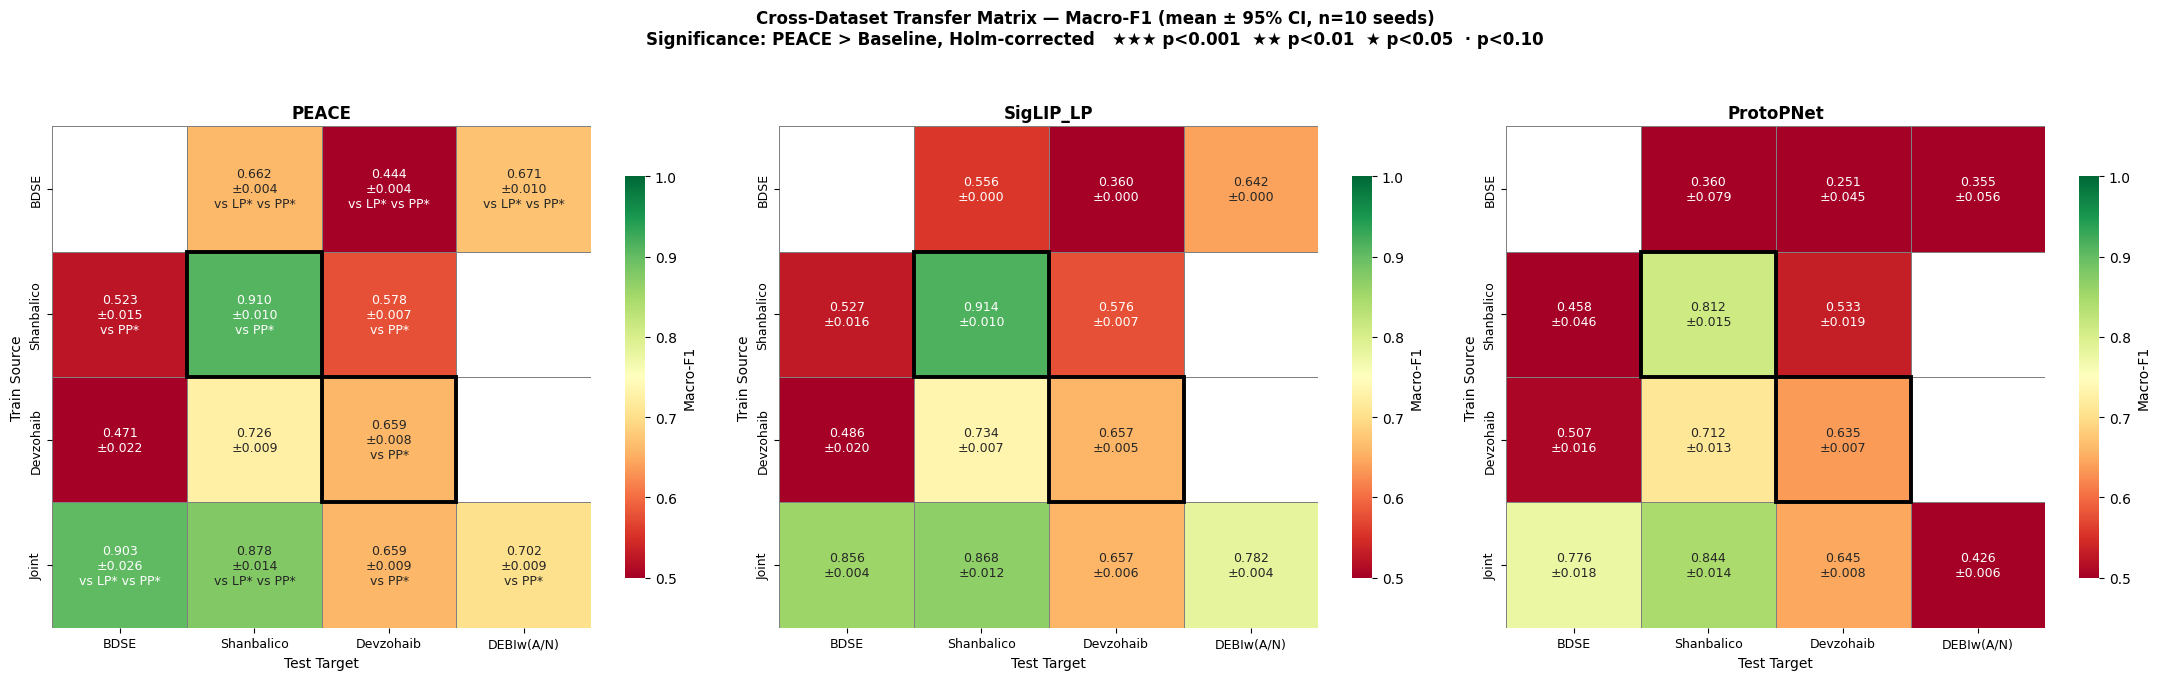

Figure 5 v3 saved: /kaggle/working/nb41_outputs/figure5_v3_transfer_with_CI_and_sig.pdf


In [23]:
# ── Figure 5 v3: macro-F1 heatmap with CI annotations + per-cell sig markers ─
SOURCE_ORDER = ['BDSE', 'Shanbalico', 'Devzohaib', 'Joint']
TARGET_ORDER = ['BDSE', 'Shanbalico', 'Devzohaib', 'DEBIw(A/N)']
METHODS_PLOT = ['PEACE', 'SigLIP_LP', 'ProtoPNet']

mf1 = agg_df[agg_df['metric']=='macro_f1']
cd_tests = tests_df[tests_df['family']=='cross_dataset']

def get_sig_for_cell(method, train_src, test_tgt, comparison_method):
    """Return Holm-corrected significance marker for PEACE > comparison."""
    sub = cd_tests[(cd_tests['train_src']==train_src) &
                    (cd_tests['test_tgt']==test_tgt) &
                    (cd_tests['method_a']==method) &
                    (cd_tests['method_b']==comparison_method)]
    if len(sub) == 0: return ''
    p = sub.iloc[-1]['p_greater_holm']
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '.'
    return ''

def build_cell_text(method):
    mat = np.full((len(SOURCE_ORDER), len(TARGET_ORDER)), np.nan)
    txt = np.full((len(SOURCE_ORDER), len(TARGET_ORDER)), '', dtype=object)
    for i, src in enumerate(SOURCE_ORDER):
        for j, tgt in enumerate(TARGET_ORDER):
            sub = mf1[(mf1['train_src']==src) & (mf1['test_tgt']==tgt) & (mf1['method']==method)]
            if len(sub) == 0: continue
            r = sub.iloc[-1]
            mat[i,j] = r['mean']
            base = f"{r['mean']:.3f}\n±{r['ci95_half']:.3f}"
            # Add significance marker for PEACE vs each baseline (only on PEACE panel)
            if method == 'PEACE':
                sig_sl = get_sig_for_cell('PEACE', src, tgt, 'SigLIP_LP')
                sig_pp = get_sig_for_cell('PEACE', src, tgt, 'ProtoPNet')
                marks = []
                if sig_sl: marks.append(f"vs LP{sig_sl}")
                if sig_pp: marks.append(f"vs PP{sig_pp}")
                if marks: base += "\n" + " ".join(marks)
            txt[i,j] = base
    return mat, txt

fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))
fig.suptitle('Cross-Dataset Transfer Matrix — Macro-F1 (mean ± 95% CI, n=10 seeds)\n'
             'Significance: PEACE > Baseline, Holm-corrected   '
             '★★★ p<0.001  ★★ p<0.01  ★ p<0.05  · p<0.10',
             fontsize=12, fontweight='bold', y=1.04)

for ax, method in zip(axes, METHODS_PLOT):
    mat, txt = build_cell_text(method)
    mask = np.isnan(mat)
    cmap = sns.color_palette('RdYlGn', as_cmap=True)
    sns.heatmap(mat, ax=ax, annot=txt, fmt='', cmap=cmap,
                vmin=0.5, vmax=1.0, mask=mask,
                xticklabels=TARGET_ORDER, yticklabels=SOURCE_ORDER,
                linewidths=0.6, linecolor='grey',
                cbar_kws={'shrink':0.8, 'label':'Macro-F1'},
                annot_kws={'fontsize':9})
    for i in range(len(SOURCE_ORDER)):
        if SOURCE_ORDER[i] in TARGET_ORDER:
            j = TARGET_ORDER.index(SOURCE_ORDER[i])
            if not np.isnan(mat[i,j]):
                ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor='black', lw=2.8))
    ax.set_title(method, fontsize=12, fontweight='bold')
    ax.set_xlabel('Test Target', fontsize=10)
    ax.set_ylabel('Train Source', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)

plt.tight_layout()
out_pdf = os.path.join(CFG['output_dir'], 'figure5_v3_transfer_with_CI_and_sig.pdf')
out_png = os.path.join(CFG['output_dir'], 'figure5_v3_transfer_with_CI_and_sig.png')
plt.savefig(out_pdf, bbox_inches='tight', dpi=300)
plt.savefig(out_png, bbox_inches='tight', dpi=300)
plt.show()
print(f"Figure 5 v3 saved: {out_pdf}")


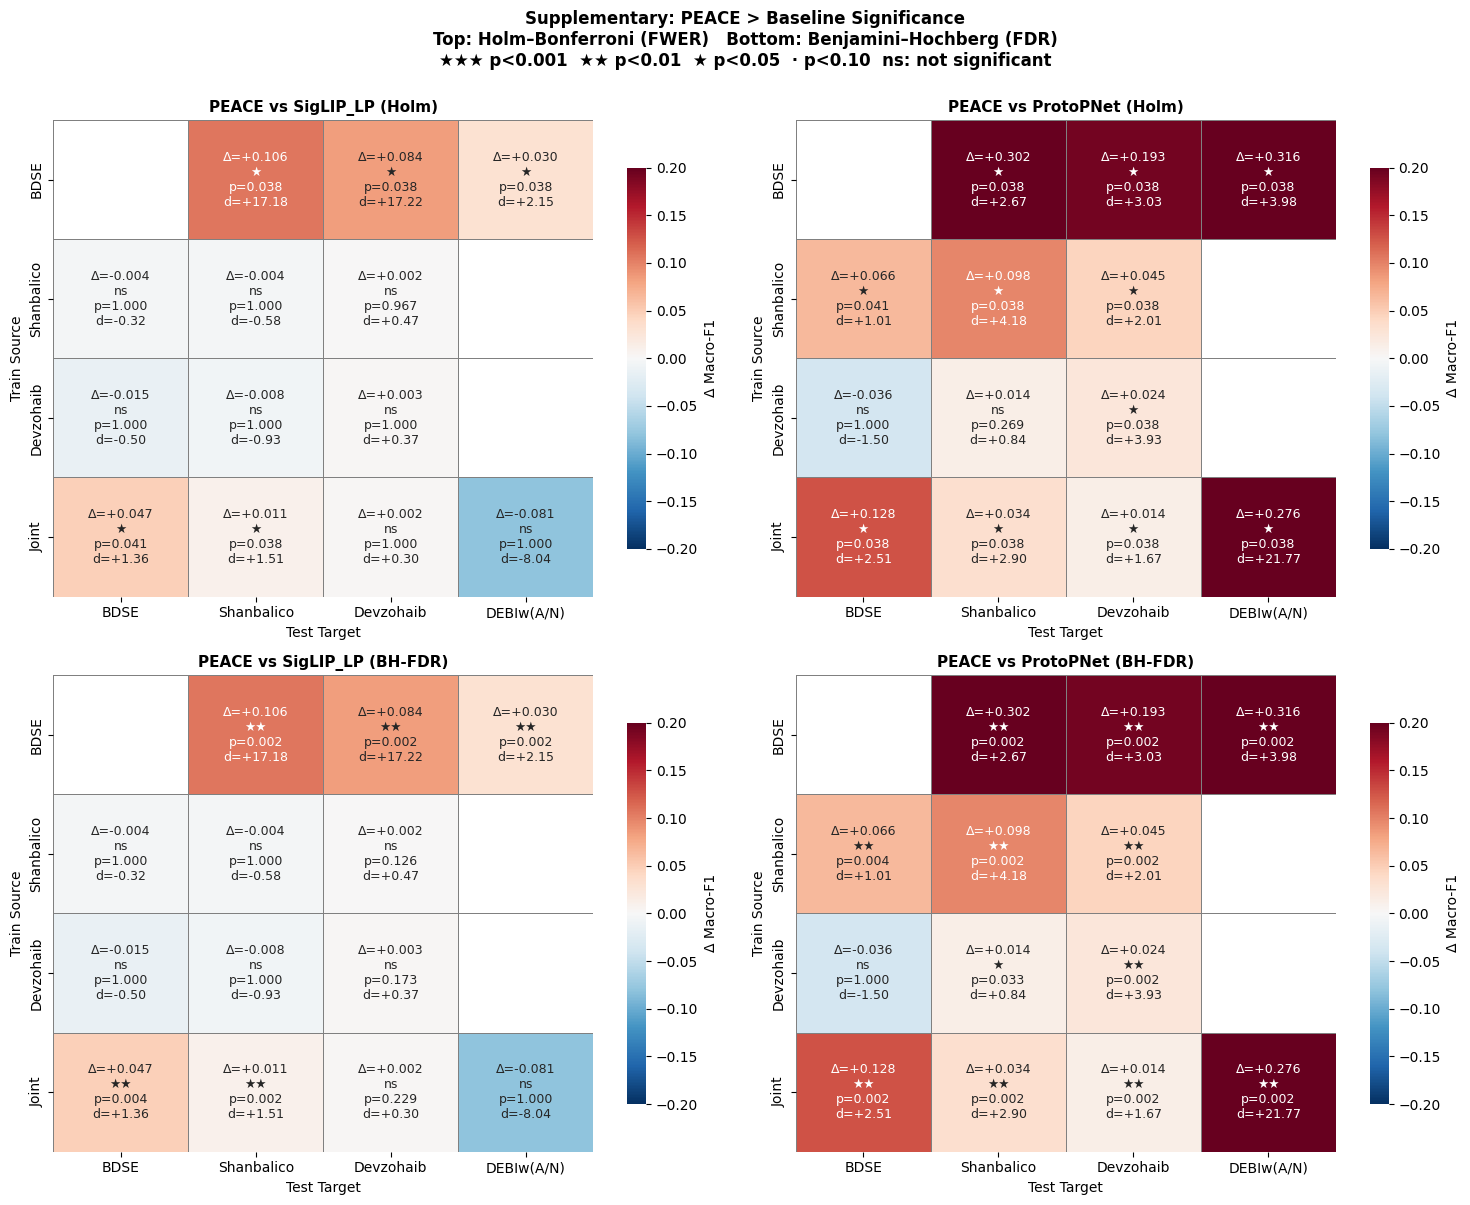

Supplementary figure saved: /kaggle/working/nb41_outputs/figure5_supp_significance_heatmap.pdf


In [24]:
# ── Supplementary: PEACE vs baseline significance heatmaps (Holm + BH-FDR) ────
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Supplementary: PEACE > Baseline Significance\n'
             'Top: Holm–Bonferroni (FWER)   Bottom: Benjamini–Hochberg (FDR)\n'
             '★★★ p<0.001  ★★ p<0.01  ★ p<0.05  · p<0.10  ns: not significant',
             fontsize=12, fontweight='bold', y=1.00)

cd = tests_df[tests_df['family']=='cross_dataset']

correction_pairs = [
    ('Holm', 'p_greater_holm'),
    ('BH-FDR', 'p_greater_bh'),
]

for row_idx, (corr_name, p_col) in enumerate(correction_pairs):
    for col_idx, baseline in enumerate(['SigLIP_LP', 'ProtoPNet']):
        ax = axes[row_idx, col_idx]
        sig_mat = np.full((len(SOURCE_ORDER), len(TARGET_ORDER)), np.nan)
        txt_mat = np.full((len(SOURCE_ORDER), len(TARGET_ORDER)), '', dtype=object)
        for i, src in enumerate(SOURCE_ORDER):
            for j, tgt in enumerate(TARGET_ORDER):
                sub = cd[(cd['train_src']==src) & (cd['test_tgt']==tgt) &
                          (cd['method_a']=='PEACE') & (cd['method_b']==baseline)]
                if len(sub) == 0: continue
                r = sub.iloc[-1]
                delta = r['delta']; ph = r[p_col]
                sig_mat[i,j] = delta
                if ph < 0.001:   mark = '★★★'
                elif ph < 0.01:  mark = '★★'
                elif ph < 0.05:  mark = '★'
                elif ph < 0.10:  mark = '·'
                else:            mark = 'ns'
                txt_mat[i,j] = f"Δ={delta:+.3f}\n{mark}\np={ph:.3f}\nd={r['cohens_d']:+.2f}"
        mask = np.isnan(sig_mat)
        sns.heatmap(sig_mat, ax=ax, annot=txt_mat, fmt='', cmap='RdBu_r',
                    center=0, vmin=-0.2, vmax=0.2, mask=mask,
                    xticklabels=TARGET_ORDER, yticklabels=SOURCE_ORDER,
                    linewidths=0.6, linecolor='grey',
                    cbar_kws={'shrink':0.8, 'label':'Δ Macro-F1'},
                    annot_kws={'fontsize':9})
        ax.set_title(f'PEACE vs {baseline} ({corr_name})', fontsize=11, fontweight='bold')
        ax.set_xlabel('Test Target', fontsize=10)
        ax.set_ylabel('Train Source', fontsize=10)

plt.tight_layout()
sup_pdf = os.path.join(CFG['output_dir'], 'figure5_supp_significance_heatmap.pdf')
sup_png = os.path.join(CFG['output_dir'], 'figure5_supp_significance_heatmap.png')
plt.savefig(sup_pdf, bbox_inches='tight', dpi=300)
plt.savefig(sup_png, bbox_inches='tight', dpi=300)
plt.show()
print(f"Supplementary figure saved: {sup_pdf}")


In [25]:
print("\n" + "="*70)
print("FINAL SUMMARY — Notebook 4.1")
print("="*70)

print(f"\n  Total raw 10-seed runs   : {len(results_df)}")
print(f"  Aggregated cells         : {len(mf1)}")
print(f"  Per-cell Wilcoxon tests  : {len(tests_df)}")
print(f"  Aggregate meta-tests     : {len(agg_meta_df)}")

# How many PEACE > baseline cells are significant under each correction?
peace_tests = tests_df[tests_df['method_a']=='PEACE']
print(f"\n  PEACE > baseline significance counts:")
print(f"    raw p<0.05         : {(peace_tests['p_greater'] < 0.05).sum()}/{len(peace_tests)}")
print(f"    Holm-corrected p<0.05 : {(peace_tests['p_greater_holm'] < 0.05).sum()}/{len(peace_tests)}")
print(f"    BH-FDR p<0.05      : {(peace_tests['p_greater_bh'] < 0.05).sum()}/{len(peace_tests)}")

print(f"\n--- Aggregate meta-tests ---")
print(agg_meta_df[['test_set','method_a','method_b','n_pairs','delta',
                    'cohens_d','rank_biserial_r','p_greater','sig_greater']].to_string(index=False))

# Files
print(f"\n--- Files in {CFG['output_dir']} ---")
for f in sorted(os.listdir(CFG['output_dir'])):
    sz = os.path.getsize(os.path.join(CFG['output_dir'], f))
    print(f"  {f:55s}  {sz/1024:.1f} KB")

print("\nDone.")



FINAL SUMMARY — Notebook 4.1

  Total raw 10-seed runs   : 390
  Aggregated cells         : 39
  Per-cell Wilcoxon tests  : 44
  Aggregate meta-tests     : 9

  PEACE > baseline significance counts:
    raw p<0.05         : 19/31
    Holm-corrected p<0.05 : 16/31
    BH-FDR p<0.05      : 17/31

--- Aggregate meta-tests ---
          test_set  method_a  method_b  n_pairs  delta  cohens_d  rank_biserial_r  p_greater sig_greater
cross_dataset_only     PEACE SigLIP_LP       70 0.0278     0.588            0.495    0.00016         ***
cross_dataset_only     PEACE ProtoPNet       70 0.1284     0.881            0.820    0.00000         ***
cross_dataset_only SigLIP_LP ProtoPNet       70 0.1007     0.860            0.860    0.00000         ***
  cross_plus_joint     PEACE SigLIP_LP      110 0.0158     0.312            0.345    0.00083         ***
  cross_plus_joint     PEACE ProtoPNet      110 0.1228     0.924            0.876    0.00000         ***
  cross_plus_joint SigLIP_LP ProtoPNet      